In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def calcular_histograma_medio(caminho_pasta, sufixos=['0', '1', '2'], caminho_exclude=None,nbins=256):
    # Inicializa estrutura para armazenar as médias
    resultados = {}
    
    # Lista de arquivos para excluir, se houver
    misclassified_imgs = []
    if caminho_exclude and os.path.exists(caminho_exclude):
        misclassified_imgs = [os.path.join(caminho_pasta, img) for img in os.listdir(caminho_exclude)]

    formatos = ['.jpg', '.jpeg', '.png']

    for suf in sufixos:
        # Acumuladores para os 3 canais
        soma_canais = [np.zeros((nbins, 1)) for _ in range(3)]
        count = 0
        
        arquivos_classe = []
        for ext in formatos:
            padrao = os.path.join(caminho_pasta, f'*{suf}{ext}')
            arquivos_classe.extend(glob.glob(padrao))
        
        for img_path in arquivos_classe:
            if img_path in misclassified_imgs:
                continue

            img = cv2.imread(img_path)
            if img is None: continue
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            for i in range(3):
                hist = cv2.calcHist([img_rgb], [i], None, [nbins], [0, 256])
                #cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
                soma_canais[i] += hist
            
            count += 1

        # Calcula a média apenas se houver imagens
        if count > 0:
            resultados[suf] = [canal / count for canal in soma_canais]
        else:
            resultados[suf] = [np.zeros((256, 1)) for _ in range(3)]
            
    return resultados

nbins=8
# Exemplo de uso:
calcular_histograma_medio('/home/alexandreselani/Desktop/Eucalyptus_preliminar/images/dataset-20', sufixos=['0','1', '2'],caminho_exclude="./misclassified/dataset-20/",nbins=nbins)
calcular_histograma_medio('/home/alexandreselani/Desktop/Eucalyptus_preliminar/misclassified/dataset-20', sufixos=['0','1', '2'],nbins=nbins)

{'0': [array([[  0.],
         [  0.],
         [  0.],
         [  0.],
         [100.],
         [  0.],
         [  0.],
         [  0.]]),
  array([[ 0.],
         [ 0.],
         [ 0.],
         [ 2.],
         [98.],
         [ 0.],
         [ 0.],
         [ 0.]]),
  array([[  0.],
         [  0.],
         [  0.],
         [100.],
         [  0.],
         [  0.],
         [  0.],
         [  0.]])],
 '1': [array([[3.58928571e+01],
         [4.83571429e+01],
         [1.40714286e+01],
         [1.35714286e+00],
         [2.85714286e-01],
         [3.57142857e-02],
         [0.00000000e+00],
         [0.00000000e+00]]),
  array([[20.53571429],
         [61.85714286],
         [15.85714286],
         [ 1.25      ],
         [ 0.32142857],
         [ 0.17857143],
         [ 0.        ],
         [ 0.        ]]),
  array([[2.58928571e+01],
         [6.46428571e+01],
         [8.78571429e+00],
         [6.42857143e-01],
         [3.57142857e-02],
         [0.00000000e+00],
         

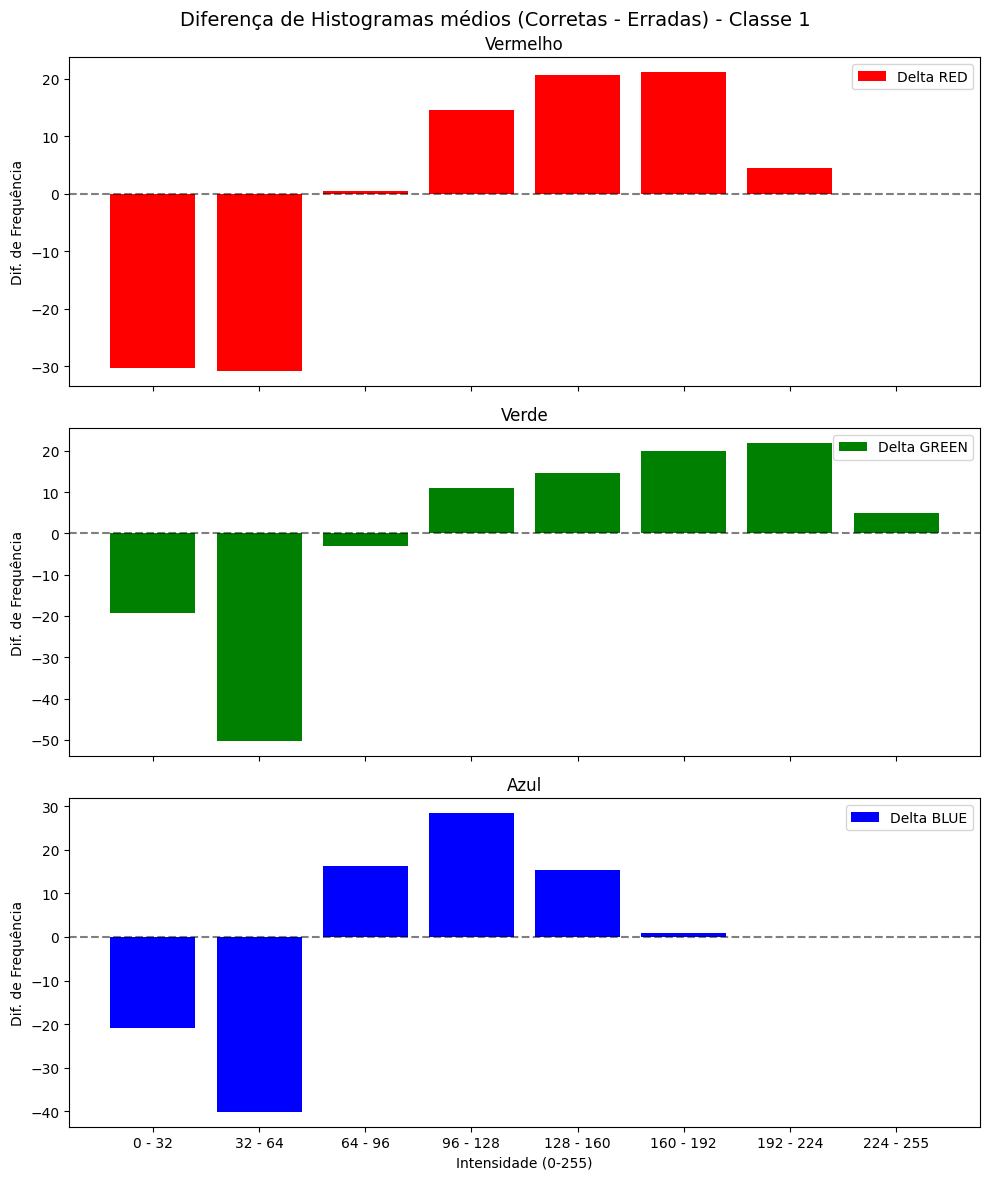

In [67]:
path_dataset = '/home/alexandreselani/Desktop/Eucalyptus_preliminar/images/dataset-20'
path_erros = '/home/alexandreselani/Desktop/Eucalyptus_preliminar/misclassified/dataset-20'

# 1. Obtém as médias
# 'corretas' = Imagens na pasta original que NÃO estão na pasta de erro
medias_corretas = calcular_histograma_medio(path_dataset, sufixos=['1'], caminho_exclude=path_erros,nbins=nbins)

# 'erradas' = Imagens que estão na pasta de erro (preditas como classe 3 mas eram outra, ou eram 3 e foram pra 2)
medias_erradas = calcular_histograma_medio(path_erros, sufixos=['1'],nbins=nbins)

# 2. Calcula a Diferença para a Classe 2 (ou a que você deseja analisar)
classe_analise = '1'
diff_hist = []

for i in range(3): # R, G, B
    # Diferença: Correta - Errada
    diff = medias_corretas[classe_analise][i] - medias_erradas[classe_analise][i]
    diff_hist.append(diff)

fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
cores = ['red', 'green', 'blue']
nomes_canais = ['Vermelho', 'Verde', 'Azul']

bin_limits = np.linspace(0,256,nbins+1,dtype=int)
x = []

for i in range(len(bin_limits)-1):
    if(i != len(bin_limits)-2):
        x.append(f"{bin_limits[i]} - {bin_limits[i+1]}")
    else:
        x.append(f"{bin_limits[i]} - {255}")



for i, cor in enumerate(cores):
    bin = np.array(diff_hist[i]).reshape(-1)
    
    # Plota no subplot correspondente (axs[0], axs[1] ou axs[2])
    axs[i].bar(x=x, height=bin, color=cor, label=f'Delta {cor.upper()}')
    axs[i].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Configurações individuais de cada gráfico
    axs[i].set_title(f"{nomes_canais[i]}")
    axs[i].set_ylabel("Dif. de Frequência")
    axs[i].legend(loc='upper right')

# Configurações gerais da figura
plt.xlabel("Intensidade (0-255)")
plt.suptitle(f"Diferença de Histogramas médios (Corretas - Erradas) - Classe {classe_analise}", fontsize=14, y=0.98)

# Ajusta o espaçamento para não sobrepor os títulos
plt.tight_layout()
plt.show()

In [68]:
# import cv2
# import matplotlib.pyplot as plt
# import glob
# import os

# def calcular_e_plotar_histogramas(caminho_pasta):
#     # Tipos de arquivos suportados
#     extensoes = ['*2.jpg', '*2.jpeg', '*2.png']
#     arquivos = []
#     for ext in extensoes:
#         arquivos.extend(glob.glob(os.path.join(caminho_pasta, ext)))

#     if not arquivos:
#         print("Nenhuma imagem encontrada na pasta especificada.")
#         return

#     # Configuração do gráfico
#     plt.figure(figsize=(15, 5 * len(arquivos)))
    
#     for i, img_path in enumerate(arquivos):
#         # Carrega a imagem (OpenCV usa padrão BGR)
#         img = cv2.imread(img_path)
#         img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
#         # Cria o subplot: Imagem à esquerda, Histograma à direita
#         plt.subplot(len(arquivos), 2, 2*i + 1)
#         plt.imshow(img_rgb)
#         plt.title(f"Imagem: {os.path.basename(img_path)}")
#         plt.axis('off')

#         plt.subplot(len(arquivos), 2, 2*i + 2)
#         cores = ('r', 'g', 'b')
        
#         # Calcula o histograma para cada canal
#         for j, cor in enumerate(cores):
#             # calcHist(imagens, canais, máscara, bins, intervalo)
#             hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
#             plt.plot(hist, color=cor)
#             plt.xlim([0, 256])
        
#         plt.title("Histograma de Cores")
#         plt.xlabel("Intensidade (0-255)")
#         plt.ylabel("Número de Pixels")

#     plt.tight_layout()
#     plt.show()

# # Exemplo de uso:
# calcular_e_plotar_histogramas('/home/alexandreselani/Desktop/Eucalyptus_preliminar/images/dataset-20')
# calcular_e_plotar_histogramas('/home/alexandreselani/Desktop/Eucalyptus_preliminar/misclassified/dataset-20')

6449 94
0.00010455192770136534


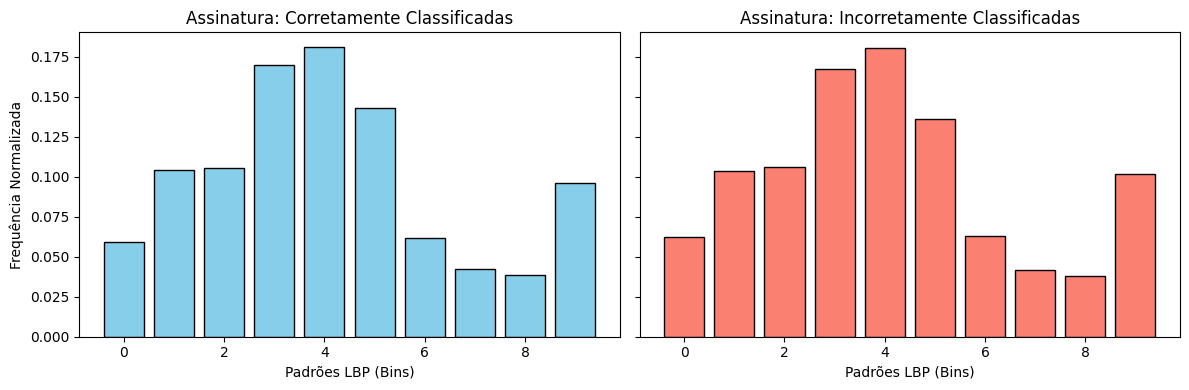

In [69]:
from skimage.feature import local_binary_pattern
import numpy as np

def get_set_signature(lista_imagens):
    hists = []
    for path in lista_imagens:
        img = cv2.imread(path)
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # P=8 (vizinhos), R=1 (raio)
        lbp = local_binary_pattern(img_gray, P=8, R=1, method='uniform')
        (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)
        hists.append(hist)
    
    
    return np.mean(hists, axis=0)

# Comparação final entre Assinatura_A e Assinatura_B
def chi_square_distance(h1, h2):
    return np.sum(((h1 - h2) ** 2) / (h1 + h2 + 1e-10))



def plot_comparacao(hist_a, hist_b, nome_a="Conjunto A", nome_b="Conjunto B"):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    
    ax[0].bar(range(len(hist_a)), hist_a, color='skyblue', edgecolor='black')
    ax[0].set_title(f'Assinatura: {nome_a}')
    ax[0].set_xlabel('Padrões LBP (Bins)')
    ax[0].set_ylabel('Frequência Normalizada')

    ax[1].bar(range(len(hist_b)), hist_b, color='salmon', edgecolor='black')
    ax[1].set_title(f'Assinatura: {nome_b}')
    ax[1].set_xlabel('Padrões LBP (Bins)')

    plt.tight_layout()
    plt.show()

incorrectly_classified_list = os.listdir("./misclassified/dataset-20/")
incorrectly_classified = [os.path.join("./misclassified/dataset-20/",img) for img in incorrectly_classified_list]
hist_incorrect = get_set_signature(incorrectly_classified)

correctly_classified_list = os.listdir("./images/dataset-20/")
correctly_classified = [os.path.join("./images/dataset-20/",img) for img in correctly_classified_list if img not in incorrectly_classified_list]
hist_correct = get_set_signature(correctly_classified)

print(len(correctly_classified),len(incorrectly_classified))
print(((hist_correct-hist_incorrect)**2).sum())
plot_comparacao(hist_correct,hist_incorrect,nome_a="Corretamente Classificadas",nome_b="Incorretamente Classificadas")